#  EDA

# 1.Setup and load data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

coverage = pd.read_csv("../data/cleaned/coverage_clean.csv")
incidence = pd.read_csv("../data/cleaned/incidence_clean.csv")
cases = pd.read_csv("../data/cleaned/cases_clean.csv")
intro = pd.read_csv("../data/cleaned/intro_clean.csv")
schedule = pd.read_csv("../data/cleaned/schedule_clean.csv")

print("Loaded all cleaned tables.")

Loaded all cleaned tables.


# 2.Summary statistics

In [5]:
print("=== Coverage summary ===")
print(coverage["COVERAGE"].describe())

print("\n=== Incidence rate summary ===")
print(incidence["INCIDENCE_RATE"].describe())

print("\n=== Reported cases summary ===")
print(cases["CASES"].describe())

=== Coverage summary ===
count    230477.000000
mean         78.032914
std          74.891697
min           0.000000
25%          69.320000
50%          88.790000
75%          96.000000
max       32000.000000
Name: COVERAGE, dtype: float64

=== Incidence rate summary ===
count    61584.000000
mean       109.448781
std        992.276983
min          0.000000
25%          0.000000
50%          0.000000
75%          4.600000
max      69101.300000
Name: INCIDENCE_RATE, dtype: float64

=== Reported cases summary ===
count    6.547000e+04
mean     4.472409e+03
std      6.114455e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      6.300000e+01
max      4.583555e+06
Name: CASES, dtype: float64


# 3.Distribution of vaccination coverage (histogram)

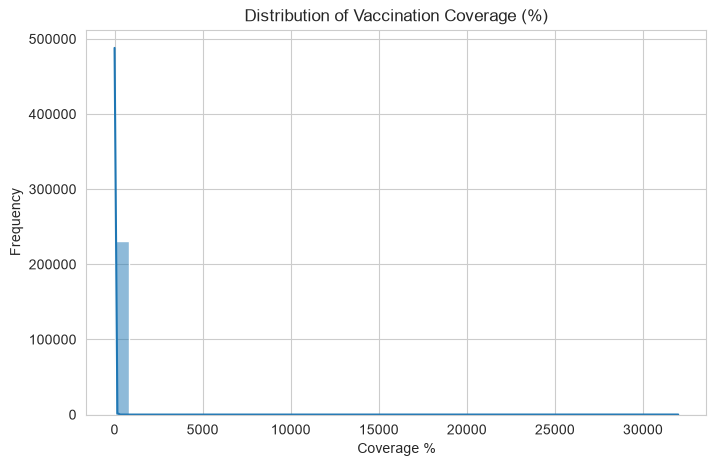

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(coverage["COVERAGE"].dropna(), bins=40, kde=True)
plt.title("Distribution of Vaccination Coverage (%)")
plt.xlabel("Coverage %")
plt.ylabel("Frequency")
plt.show()

# 4.Global average coverage trend over time (line chart)

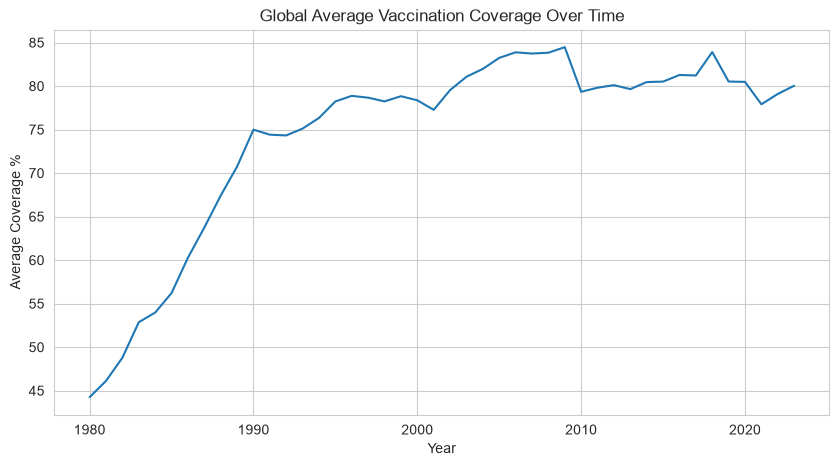

In [7]:
yearly_coverage = coverage.groupby("YEAR")["COVERAGE"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_coverage, x="YEAR", y="COVERAGE")
plt.title("Global Average Vaccination Coverage Over Time")
plt.xlabel("Year")
plt.ylabel("Average Coverage %")
plt.show()

# 5.Top and bottom 10 countries by average coverage

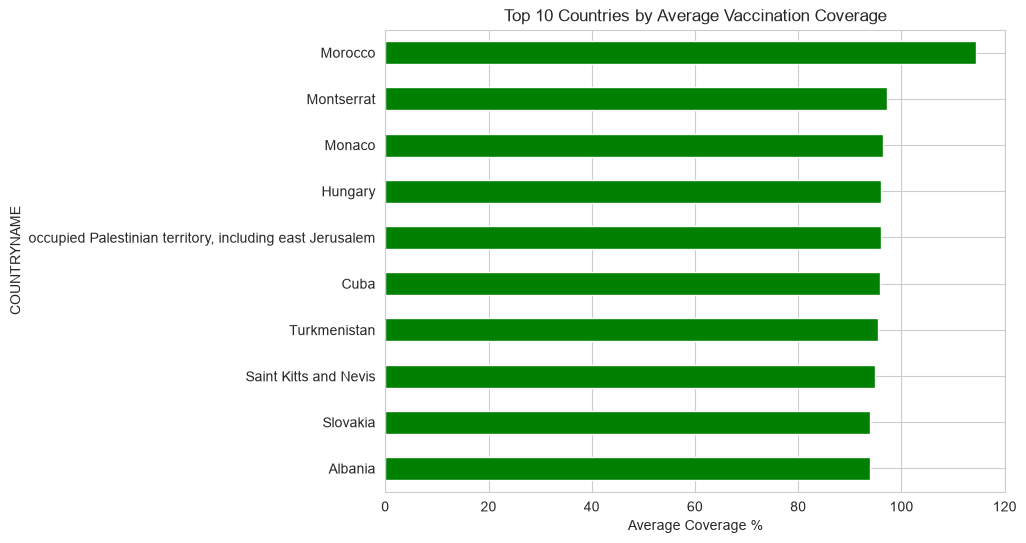

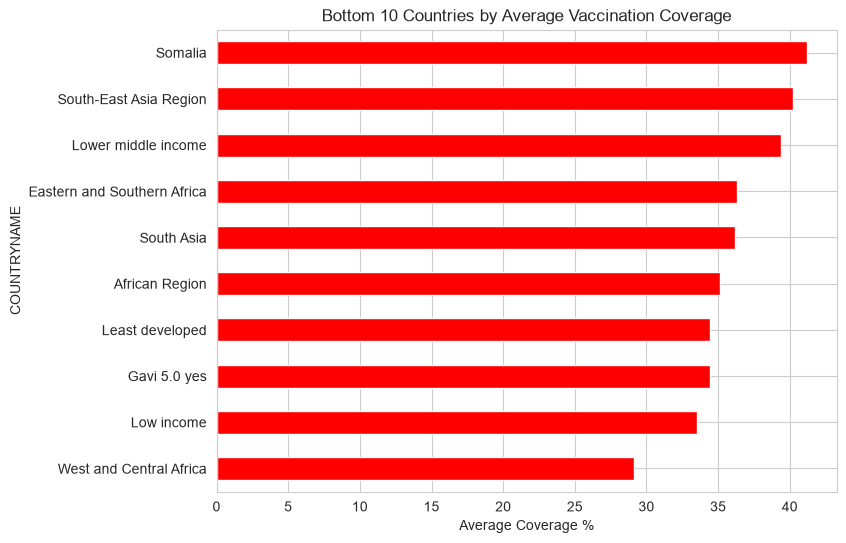

In [8]:
country_avg = coverage.groupby("COUNTRYNAME")["COVERAGE"].mean().dropna().sort_values()

plt.figure(figsize=(8,6))
country_avg.tail(10).plot(kind="barh", color="green")
plt.title("Top 10 Countries by Average Vaccination Coverage")
plt.xlabel("Average Coverage %")
plt.show()

plt.figure(figsize=(8,6))
country_avg.head(10).plot(kind="barh", color="red")
plt.title("Bottom 10 Countries by Average Vaccination Coverage")
plt.xlabel("Average Coverage %")
plt.show()

# 6.Disease incidence trend over time (line chart, top diseases)

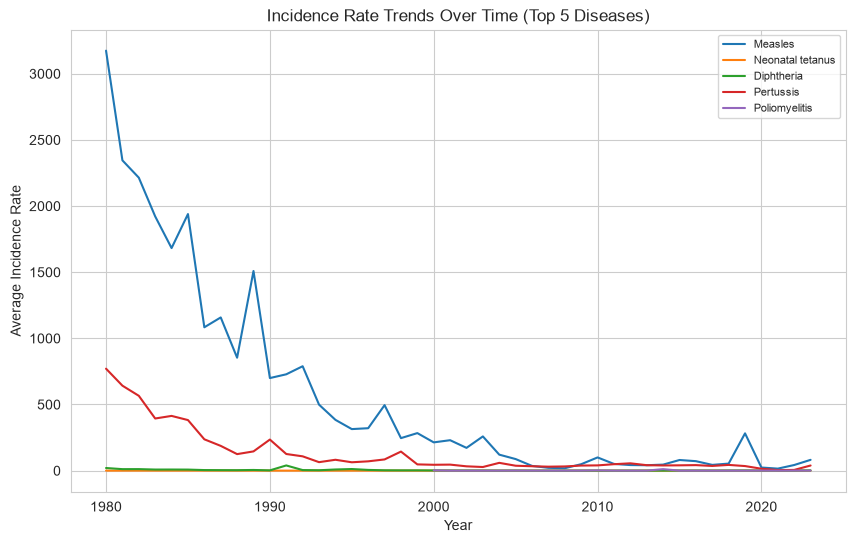

In [9]:
top_diseases = incidence["DISEASE_DESCRIPTION"].value_counts().head(5).index

plt.figure(figsize=(10,6))
for disease in top_diseases:
    subset = incidence[incidence["DISEASE_DESCRIPTION"] == disease]
    yearly = subset.groupby("YEAR")["INCIDENCE_RATE"].mean()
    plt.plot(yearly.index, yearly.values, label=disease)

plt.title("Incidence Rate Trends Over Time (Top 5 Diseases)")
plt.xlabel("Year")
plt.ylabel("Average Incidence Rate")
plt.legend(fontsize=8)
plt.show()

# 7.Correlation: coverage vs. incidence (scatter plot)

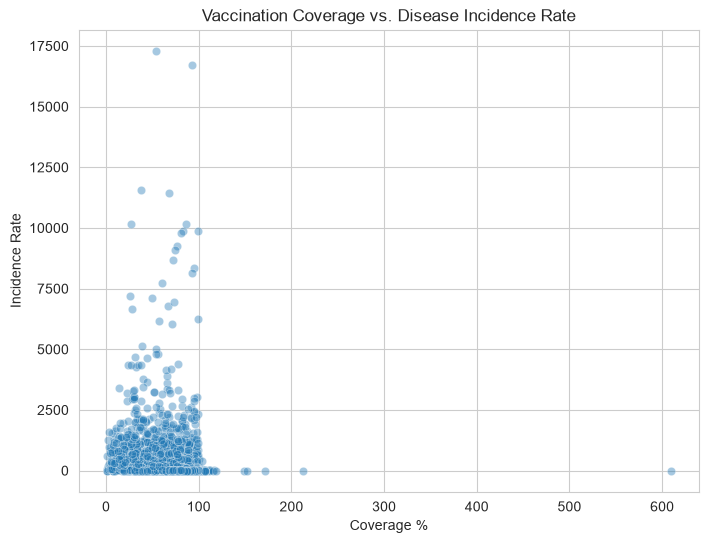

Correlation coefficient: -0.1912995783569935


In [10]:
cov_yearly = coverage.groupby(["ISO_3_CODE", "YEAR"])["COVERAGE"].mean().reset_index()
inc_yearly = incidence.groupby(["ISO_3_CODE", "YEAR"])["INCIDENCE_RATE"].mean().reset_index()

merged = pd.merge(cov_yearly, inc_yearly, on=["ISO_3_CODE", "YEAR"], how="inner")

plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="COVERAGE", y="INCIDENCE_RATE", alpha=0.4)
plt.title("Vaccination Coverage vs. Disease Incidence Rate")
plt.xlabel("Coverage %")
plt.ylabel("Incidence Rate")
plt.show()

correlation = merged["COVERAGE"].corr(merged["INCIDENCE_RATE"])
print("Correlation coefficient:", correlation)

# 8.Correlation heatmap (numeric columns in coverage)

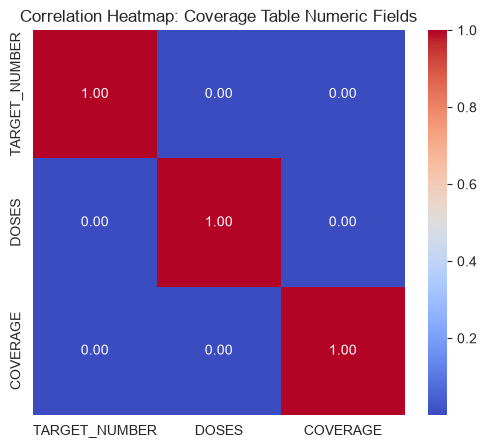

In [11]:
numeric_cols = coverage[["TARGET_NUMBER", "DOSES", "COVERAGE"]]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Coverage Table Numeric Fields")
plt.show()

#  9.Normalize Units check

In [12]:
print("=== Coverage ===")
print("Range:", coverage["COVERAGE"].min(), "-", coverage["COVERAGE"].max())
print("Rows with coverage > 100:", (coverage["COVERAGE"] > 100).sum())
print("Rows with coverage < 0:", (coverage["COVERAGE"] < 0).sum())

print("\n=== Incidence Rate ===")
print("Range:", incidence["INCIDENCE_RATE"].min(), "-", incidence["INCIDENCE_RATE"].max())
print("Denominator types used:")
print(incidence["DENOMINATOR"].value_counts())

print("\n=== Reported Cases ===")
print("Range:", cases["CASES"].min(), "-", cases["CASES"].max())
print("Any negative cases?", (cases["CASES"] < 0).sum())

=== Coverage ===
Range: 0.0 - 32000.0
Rows with coverage > 100: 5097
Rows with coverage < 0: 0

=== Incidence Rate ===
Range: 0.0 - 69101.3
Denominator types used:
DENOMINATOR
per 1,000,000 total population    61480
per 1,000,000 <15 population       9130
per 1,000 live births              8874
per 10,000 live births             5153
per 1000 live births                308
Name: count, dtype: int64

=== Reported Cases ===
Range: 0.0 - 4583555.0
Any negative cases? 0


# 10.Foreign key fix for vaccine_introduction / vaccine_schedule

In [14]:
vaccine_names_lookup = set(coverage["ANTIGEN_DESCRIPTION"].dropna().unique())

intro_names = set(intro["DESCRIPTION"].dropna().unique())
schedule_names = set(schedule["VACCINE_DESCRIPTION"].dropna().unique())

print("Vaccine names in intro NOT found in coverage's antigen list:")
print(intro_names - vaccine_names_lookup)

print("\nVaccine names in schedule NOT found in coverage's antigen list:")
print(schedule_names - vaccine_names_lookup)

Vaccine names in intro NOT found in coverage's antigen list:
{'Seasonal Influenza vaccine', 'HPV (Human Papilloma Virus) vaccine', 'IPV (Inactivated polio vaccine) 2nd dose', 'Meningococcal meningitis vaccines (all strains)', 'Hib (Haemophilus influenzae type B) vaccine', 'PCV (Pneumococcal conjugate vaccine)', 'PPV (Pneumococcal polysaccharide vaccine)', 'Mumps vaccine', 'Varicella vaccine', 'Hepatitis A vaccine', 'Japanese Encephalitis', 'YF (Yellow fever) vaccine', 'Measles-containing vaccine 2nd dose', 'Malaria vaccine', 'Hepatitis B vaccine', 'aP (acellular pertussis) vaccine', 'HepB birth dose', 'Rotavirus vaccine', 'IPV (Inactivated polio vaccine)', 'Rubella vaccine'}

Vaccine names in schedule NOT found in coverage's antigen list:
{'MR (Measles and rubella) vaccine', 'MMRV (Measles, mumps, rubella and varicella) vaccine', 'Hemorrhagic fever with renal syndrome vaccine', 'PCV-15 (Pneumococcal conjugate vaccine 15-valent) vaccine', 'DT-IPV (Diphtheria and tetanus toxoid and IPV) 

In [15]:
bad_coverage = coverage[coverage["COVERAGE"] > 100]
print("Coverage categories among >100% rows:")
print(bad_coverage["COVERAGE_CATEGORY_DESCRIPTION"].value_counts())
print("\nSample rows:")
print(bad_coverage[["COUNTRYNAME", "YEAR", "ANTIGEN_DESCRIPTION", "COVERAGE_CATEGORY_DESCRIPTION", "TARGET_NUMBER", "DOSES", "COVERAGE"]].head(10))

Coverage categories among >100% rows:
COVERAGE_CATEGORY_DESCRIPTION
Administrative coverage    3373
Official coverage          1724
Name: count, dtype: int64

Sample rows:
      COUNTRYNAME  YEAR                       ANTIGEN_DESCRIPTION  \
1247  Afghanistan  2015          DTP-containing vaccine, 1st dose   
1248  Afghanistan  2015          DTP-containing vaccine, 1st dose   
1275  Afghanistan  2015  Pneumococcal conjugate vaccine, 1st dose   
1276  Afghanistan  2015  Pneumococcal conjugate vaccine, 1st dose   
1307  Afghanistan  2014                                       BCG   
1310  Afghanistan  2014          DTP-containing vaccine, 1st dose   
1313  Afghanistan  2014          DTP-containing vaccine, 3rd dose   
1319  Afghanistan  2014                            HepB, 3rd dose   
1322  Afghanistan  2014                             Hib, 3rd dose   
1337  Afghanistan  2014  Pneumococcal conjugate vaccine, 1st dose   

     COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER      DOSES  COVERA

In [16]:
print("Rows with coverage > 500%:", (coverage["COVERAGE"] > 500).sum())
print(coverage[coverage["COVERAGE"] > 500][["COUNTRYNAME", "YEAR", "ANTIGEN_DESCRIPTION", "COVERAGE"]].sort_values("COVERAGE", ascending=False).head(10))

Rows with coverage > 500%: 9
                             COUNTRYNAME  YEAR  \
207060                           Morocco  2018   
117327  Micronesia (Federated States of)  2020   
4683                            Anguilla  2020   
217675                  Marshall Islands  2023   
138238                         Guatemala  2018   
3296                              Angola  2014   
235477                        Montserrat  2000   
324055                        Seychelles  2022   
322120                          Eswatini  2021   

                                   ANTIGEN_DESCRIPTION  COVERAGE  
207060    Influenza travellers (incl. Hajj pilgrimage)   32000.0  
117327                             Vitamin A, 1st dose    6604.0  
4683                            HPV Female, final dose    6100.0  
217675                             Vitamin A, 1st dose    4868.0  
138238                     Influenza child age group 1    2630.0  
3296    Inactivated polio-containing vaccine, 1st dose    1035.0  
2

# 11.Fix missing WHO region data

In [17]:
# Check WHO region coverage across all sources that have it
intro_regions = intro[["ISO_3_CODE", "WHO_REGION"]].drop_duplicates()
schedule_regions = schedule[["ISO_3_CODE", "WHO_REGION"]].drop_duplicates()

print("Unique countries with WHO region in intro:", intro_regions["ISO_3_CODE"].nunique())
print("Unique countries with WHO region in schedule:", schedule_regions["ISO_3_CODE"].nunique())
print("Total unique countries overall:", coverage["ISO_3_CODE"].nunique())

Unique countries with WHO region in intro: 194
Unique countries with WHO region in schedule: 213
Total unique countries overall: 245


In [18]:
# Combine WHO region info from both intro and schedule (schedule has more coverage)
combined_regions = pd.concat([
    schedule[["ISO_3_CODE", "WHO_REGION"]],
    intro[["ISO_3_CODE", "WHO_REGION"]]
]).dropna().drop_duplicates(subset=["ISO_3_CODE"], keep="first")

print("Countries with a WHO region after combining both sources:", combined_regions["ISO_3_CODE"].nunique())

# Which countries are still missing a region?
all_countries = set(coverage["ISO_3_CODE"].unique())
have_region = set(combined_regions["ISO_3_CODE"].unique())
missing = all_countries - have_region

print("\nStill missing WHO region:", len(missing))
print(sorted(missing))# Combine WHO region info from both intro and schedule (schedule has more coverage)
combined_regions = pd.concat([
    schedule[["ISO_3_CODE", "WHO_REGION"]],
    intro[["ISO_3_CODE", "WHO_REGION"]]
]).dropna().drop_duplicates(subset=["ISO_3_CODE"], keep="first")

print("Countries with a WHO region after combining both sources:", combined_regions["ISO_3_CODE"].nunique())

# Which countries are still missing a region?
all_countries = set(coverage["ISO_3_CODE"].unique())
have_region = set(combined_regions["ISO_3_CODE"].unique())
missing = all_countries - have_region

print("\nStill missing WHO region:", len(missing))
print(sorted(missing))

Countries with a WHO region after combining both sources: 213

Still missing WHO region: 32
['AFR', 'AMR', 'ASM', 'DEVELOPED_ECONOMY', 'DEVELOPING', 'ECONOMY_IN_TRANSITION', 'EMR', 'EUR', 'GAVI_PHASE5_NO', 'GAVI_PHASE5_YES', 'GLOBAL', 'LEAST_DEVELOPED', 'SEAR', 'UNICEF_REGIONS_CEE_CIS', 'UNICEF_REGIONS_DEV', 'UNICEF_REGIONS_EAPRO', 'UNICEF_REGIONS_ESARO', 'UNICEF_REGIONS_LACRO', 'UNICEF_REGIONS_MENA', 'UNICEF_REGIONS_ROSA', 'UNICEF_REGIONS_WCARO', 'WB_LONG_HIC_NONOECD', 'WB_LONG_HIC_OECD', 'WB_LONG_LIC', 'WB_LONG_LMIC', 'WB_LONG_NA', 'WB_LONG_UMIC', 'WB_SHORT_HIC', 'WB_SHORT_LIC', 'WB_SHORT_MIC', 'WB_SHORT_NA', 'WPR']
Countries with a WHO region after combining both sources: 213

Still missing WHO region: 32
['AFR', 'AMR', 'ASM', 'DEVELOPED_ECONOMY', 'DEVELOPING', 'ECONOMY_IN_TRANSITION', 'EMR', 'EUR', 'GAVI_PHASE5_NO', 'GAVI_PHASE5_YES', 'GLOBAL', 'LEAST_DEVELOPED', 'SEAR', 'UNICEF_REGIONS_CEE_CIS', 'UNICEF_REGIONS_DEV', 'UNICEF_REGIONS_EAPRO', 'UNICEF_REGIONS_ESARO', 'UNICEF_REGIONS_

In [19]:
combined_regions = pd.concat([
    schedule[["ISO_3_CODE", "WHO_REGION"]],
    intro[["ISO_3_CODE", "WHO_REGION"]]
]).dropna().drop_duplicates(subset=["ISO_3_CODE"], keep="first")

# Manual patch for American Samoa (real territory, missing from both sources)
manual_patch = pd.DataFrame([{"ISO_3_CODE": "ASM", "WHO_REGION": "WPR"}])
combined_regions = pd.concat([combined_regions, manual_patch]).drop_duplicates(subset=["ISO_3_CODE"], keep="first")

combined_regions.to_csv("../data/cleaned/who_regions.csv", index=False)
print("Saved combined WHO region mapping:", combined_regions.shape)

Saved combined WHO region mapping: (214, 2)
